# Loan Default Risk Analysis Using Exploratory Data Analysis

<img src="CanvaCreditRisk.png" alt="Loan Default Risk Analysis" width="600"/>

## Introduction
This assignment aims to give you an idea of applying EDA in a real business scenario. In this assignment, apart from applying the techniques that you have learnt in the EDA module, you will also develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimise the risk of losing money while lending to customers.

## Business Understanding
The loan-providing companies find it hard to give loans to people due to their insufficient or non-existent credit history. Because of that, some consumers use it to their advantage by becoming a defaulter. Suppose you work for a consumer finance company specialising in lending various types of loans to urban customers. You have to use EDA to analyse the patterns present in the data. This will ensure that the applicants capable of repaying the loan are not rejected.

When the company receives a loan application, the company has to decide on loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:

- **If the applicant is likely to repay the loan, then not approving the loan results in a loss of business for the company.**
- **If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company.**


The data given below contains information about the loan application at the time of applying for the loan. It contains two types of scenarios:

- **The client with payment difficulties: he/she had a late payment of more than X days on at least one of the first Y instalments of the loan in our sample,**
- **All other cases: All other cases when the payment is paid on time.**


When a client applies for a loan, there are four types of decisions that could be taken by the client/company):

- **Approved: The company has approved the loan application**
- **Cancelled: The client cancelled the application sometime during approval. Either the client changed her/his mind about the loan or in some cases due to a higher risk of the client, he received worse pricing which he did not want.**
- **Refused: The company had rejected the loan (because the client does not meet their requirements etc.).**
- **Unused offer: The loan has been cancelled by the client but at different stages of the process.**


In this case study, you will use EDA to understand how consumer attributes and loan attributes influence the tendency to default.

## Business Objectives
This case study aims to identify patterns which indicate if a client has difficulty paying their instalments which may be used for taking actions such as denying the loan, reducing the amount of the loan, lending (to risky applicants) at a higher interest rate, etc. This will ensure that the consumers capable of repaying the loan are not rejected. Identification of such applicants using EDA is the aim of this case study.


In other words, the company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default.  The company can utilise this knowledge for its portfolio and risk assessment.

To develop your understanding of the domain, you are advised to independently research a little about risk analytics - understanding the types of variables and their significance should be enough.

## Data Understanding
The dataset consists of three files:

- **application_data.csv**: contains all the information of the client at the time of application. The data is about whether a client has payment difficulties.
- **previous_application.csv**: contains information about the client’s previous loan data. It contains the data on whether the previous application had been Approved, Cancelled, Refused or Unused offer.
- **columns_description.csv**: data dictionary which describes the meaning of the variables.

# 1. Basic Requirements

## 1.1 Important Libraries

In [ ]:
pip install plotly

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
pd.set_option('display.max_columns', 300) #Setting column display limit
plt.style.use('ggplot') #Applying style to graphs

## 1.2 Dataset used for Anylysis

- **application_data.csv**  *as*  **`df1`**
- **previous_application.csv**  *as*  **`df2`**

# 2. Loading  Data "application_data.csv"

**2.0.1 Reading file**

In [ ]:
df1 = pd.read_csv("application_data.csv")
df1.head()

## 2.1 Inspecting The Dataframe

**2.1.1 Checking the number of rows and columns in the dataframe by using shape() func.**

In [ ]:
df1.shape       

**2.1.2 Checking no. of columns with diffrent datatypes**

In [ ]:
df1.info(verbose = True)

**2.1.3 Checking the summary for the numeric columns**

In [ ]:
df1.describe()

**2.1.4 Sorting Percentage of null values in each column in desending  order**

In [ ]:
(df1.isnull().sum()/len(df1)*100).sort_values(ascending = False).head(50)

## 2.2 Data Cleaning

**2.2.1 List of Columns & null counts where null values are more than 35%**

In [ ]:
null_col = df1.isnull().sum().sort_values(ascending = False)
null_col = null_col[null_col.values >(0.35*len(df1))]


#Plotting Bar Graph for null values greater than 35%

plt.figure(figsize=(20,4))
null_col.plot(kind='bar', color="#4CB391")                           
plt.title('List of Columns & null counts where null values are more than 35%') 

plt.xlabel("Null Columns",fontdict={"fontsize":12,"fontweight":5})                  #Setting X-label and Y-label
plt.ylabel("Count of null values",fontdict={"fontsize":12,"fontweight":5})
plt.show()


**2.2.2 Total no.of columns having percentage of null values > 35%**

In [ ]:
len(null_col)

**2.2.3 Removing the columns having percentage of null values > 35%**

In [ ]:
label = list(null_col.index.values) #Making list of column names having null values greater than 35%
df1.drop(labels = label,axis=1,inplace = True) #Droping those columns

**2.2.4 Shape of new data frame after removing null values >35%**

In [ ]:
df1.shape

**2.2.5 Checking the % of null values for each column in new dataset again for confirmation**

In [ ]:
null = (df1.isnull().sum()/len(df1)*100).sort_values(ascending = False).head(50)
null.head(30)

## 2.3 Handling Missing Values

### 2.3.1 Imputing Columns having null values ≤ 19% with Mode values for numeric columns except for continuous numeric columns we imputed with Median value

In [ ]:

df1.AMT_REQ_CREDIT_BUREAU_YEAR.fillna(df1.AMT_REQ_CREDIT_BUREAU_YEAR.mode()[0],inplace = True) #AMT_REQ_CREDIT_BUREAU_YEAR

df1.AMT_REQ_CREDIT_BUREAU_MON.fillna(df1.AMT_REQ_CREDIT_BUREAU_MON.mode()[0],inplace = True)   #AMT_REQ_CREDIT_BUREAU_MON  

df1.AMT_REQ_CREDIT_BUREAU_WEEK.fillna(df1.AMT_REQ_CREDIT_BUREAU_WEEK.mode()[0],inplace = True) #AMT_REQ_CREDIT_BUREAU_WEEK

df1.AMT_REQ_CREDIT_BUREAU_DAY.fillna(df1.AMT_REQ_CREDIT_BUREAU_DAY.mode()[0],inplace = True)   #AMT_REQ_CREDIT_BUREAU_DAY

df1.AMT_REQ_CREDIT_BUREAU_HOUR.fillna(df1.AMT_REQ_CREDIT_BUREAU_HOUR.mode()[0],inplace = True) #AMT_REQ_CREDIT_BUREAU_HOUR

df1.AMT_REQ_CREDIT_BUREAU_QRT.fillna(df1.AMT_REQ_CREDIT_BUREAU_QRT.mode()[0],inplace = True)   #AMT_REQ_CREDIT_BUREAU_QRT

df1.NAME_TYPE_SUITE.fillna(df1.NAME_TYPE_SUITE.mode()[0],inplace = True) #NAME_TYPE_SUITE

df1.OBS_30_CNT_SOCIAL_CIRCLE.fillna( df1.OBS_30_CNT_SOCIAL_CIRCLE.mode()[0],inplace = True) #OBS_30_CNT_SOCIAL_CIRCLE

df1.DEF_30_CNT_SOCIAL_CIRCLE.fillna( df1.DEF_30_CNT_SOCIAL_CIRCLE.mode()[0],inplace = True) #DEF_30_CNT_SOCIAL_CIRCLE

df1.OBS_60_CNT_SOCIAL_CIRCLE.fillna( df1.OBS_60_CNT_SOCIAL_CIRCLE.mode()[0],inplace = True) #OBS_60_CNT_SOCIAL_CIRCLE

df1.DEF_60_CNT_SOCIAL_CIRCLE.fillna( df1.DEF_60_CNT_SOCIAL_CIRCLE.mode()[0],inplace = True) #DEF_60_CNT_SOCIAL_CIRCLE

df1.CNT_FAM_MEMBERS.fillna(df1.CNT_FAM_MEMBERS.mode() , inplace = True) #CNT_FAM_MEMBERS

df1.DAYS_LAST_PHONE_CHANGE.fillna(df1.DAYS_LAST_PHONE_CHANGE.mode()[0],inplace = True) #DAYS_LAST_PHONE_CHANGE

df1.EXT_SOURCE_2.fillna(df1.EXT_SOURCE_2.median() , inplace = True) #EXT_SOURCE_2

df1.EXT_SOURCE_3.fillna(df1.EXT_SOURCE_3.median() , inplace = True) #EXT_SOURCE_3

**2.3.3 Checking  if there are still null values or not in the dataframe accept column "OCCUPATION_TYPE"**

In [ ]:
(df1.isnull().sum()/len(df1)*100).sort_values(ascending=False)

### Note: 

- **Please ignore OCCUPATION_TYPE will handle the null values upcoming steps with the help of third variables if possible**

## 2.4 Handling Errors in Data types and Data

**2.4.1**

**We can  Changed the below columns**

*'DAYS_BIRTH',* 

*'DAYS_EMPLOYED',* 

*'DAYS_REGISTRATION',* 

*'DAYS_ID_PUBLISH'*

*'DAYS_LAST_PHONE_CHANGE'* 

**which had negative or mixed values and imputed them with absolute values for our analysis.**

In [ ]:
df1[["DAYS_BIRTH","DAYS_EMPLOYED","DAYS_REGISTRATION","DAYS_ID_PUBLISH","DAYS_LAST_PHONE_CHANGE"]]

**2.4.2 Collecting columns starting with 'DAYS' in the list "day_cols"**

In [ ]:
day_cols = [i for i in df1 if i.startswith('DAYS')]
day_cols

**2.4.3 Applying abs() function to columns starting with 'DAYS' to convert the negative values to positive**

In [ ]:
df1[day_cols]= abs(df1[day_cols])

In [ ]:
print(df1['DAYS_BIRTH'].unique())
print(df1['DAYS_EMPLOYED'].unique())
print(df1['DAYS_REGISTRATION'].unique())
print(df1['DAYS_ID_PUBLISH'].unique())
print(df1['DAYS_LAST_PHONE_CHANGE'].unique())

**2.4.4 Changing** **"Y"** **and** **"N"** **with 1 and 0 for** **columns** 

- **`FLAG_OWN_CAR`**

- **`FLAG_OWN_REALTY`**

In [ ]:
df1['FLAG_OWN_CAR'] = np.where(df1['FLAG_OWN_CAR']=='Y', 1 , 0)

df1['FLAG_OWN_REALTY'] = np.where(df1['FLAG_OWN_REALTY']=='Y', 1 , 0)

In [ ]:
df1[['FLAG_OWN_CAR','FLAG_OWN_REALTY']].head()

**2.4.5 As per below information we can impute the value'XNA' to "F" in the column  'CODE_GENDER" as the most frequent value is `F`**

In [ ]:
df1.CODE_GENDER.value_counts()

In [ ]:
df1.loc[df1.CODE_GENDER == 'XNA','CODE_GENDER'] = 'F'
df1.CODE_GENDER.value_counts()

**2.4.6 Cheking and Imputing column ORGANIZATION_TYPE'**

In [ ]:
df1.ORGANIZATION_TYPE.value_counts().head()

- Let's see if the value is `Missing Completely At Random(MCAR)`,`Missing At Random(MAR)`,`Missing Not At Random(MNAR)`

In [ ]:
df1[['ORGANIZATION_TYPE','NAME_INCOME_TYPE']].head(30)

- Here we observe that wherever `NAME_INCOME_TYPE` is ___Pensioner___ there only we have null values in `ORGANIZATON_TYPE` column.Let's see count of Pensioner and then we'll decide whether to impute null values of `ORGANIZATION_TYPE` with Pensioner or not.

In [ ]:
df1.NAME_INCOME_TYPE.value_counts()    #Check the counts for each in NAME_INCOME_TYPE

- So from these data we can conclude that, Pensioner value is approximately equal to null values in `ORGANIZATION_TYPE` column.So the value is `Missing At Random`


- Similarly imputing null values of `OCCUPATION_TYPE` with ___Pensioner___ as most of the null values for OCCUPATION_TYPE compare to Income type variable values we found that "___Pensioner___" is most frequent value almost 80% of teh null values of OCCUPATION_TYPE

In [ ]:
df1['ORGANIZATION_TYPE'] = df1['ORGANIZATION_TYPE'].replace('XNA', 'Pensioner')
df1['OCCUPATION_TYPE'].fillna('Pensioner' , inplace = True)

## 2.5 Binning of continuous variables

**2.5.1 Binning 'AMT_INCOME_TOTAL' to AMT_INCOME_TYPE based on quantiles**

In [ ]:
df1['AMT_INCOME_TYPE'] = pd.qcut(df1.AMT_INCOME_TOTAL, q=[0, 0.2, 0.5, 0.8, 0.95, 1], labels=['VERY_LOW', 'LOW', "MEDIUM", 'HIGH', 'VERY_HIGH'])
df1['AMT_INCOME_TYPE'].head(11)

**2.5.2 Binning 'AMT_CREDIT' to 'AMT_CREDIT_TYPE' based on quantiles**

In [ ]:
df1['AMT_CREDIT_TYPE'] = pd.qcut(df1.AMT_CREDIT, q=[0, 0.2, 0.5, 0.8, 0.95, 1], labels=['VERY_LOW', 'LOW', "MEDIUM", 'HIGH', 'VERY_HIGH'])
df1['AMT_CREDIT_TYPE'].head(11)

**2.5.3 Binning 'DAYS_BIRTH' column  by converting it to years based on various "AGE_GROUP"**

In [ ]:
df1['DAYS_BIRTH']= (df1['DAYS_BIRTH']/365).astype(int)    # Converting 
df1['DAYS_BIRTH'].unique()


In [ ]:
df1['AGE_GROUP']=pd.cut(df1['DAYS_BIRTH'],                 
                         bins=[19,25,35,60,100], labels=['Very_Young','Young', 'Middle_Age', 'Senior_Citizen'])   #Binning

In [ ]:
df1[['DAYS_BIRTH','AGE_GROUP']].head()    

# 3. Analysis

## 3.1 Dataypes Conversion's for better understanding of Variables

In [ ]:
df1.info()

**3.1.1 Found out few catogrical columns are showing dtype as "object" hence changing dtypes of columns from object to "categorical"**

In [ ]:
df1['NAME_CONTRACT_TYPE'] = df1['NAME_CONTRACT_TYPE'].astype('category')
df1['CODE_GENDER'] = df1['CODE_GENDER'].astype('category')
df1['NAME_TYPE_SUITE'] = df1['NAME_TYPE_SUITE'].astype('category')
df1['NAME_INCOME_TYPE'] = df1['NAME_INCOME_TYPE'].astype('category')
df1['NAME_EDUCATION_TYPE'] = df1['NAME_EDUCATION_TYPE'].astype('category')
df1['NAME_FAMILY_STATUS'] = df1['NAME_FAMILY_STATUS'].astype('category')
df1['NAME_HOUSING_TYPE'] = df1['NAME_HOUSING_TYPE'].astype('category')
df1['OCCUPATION_TYPE'] = df1['OCCUPATION_TYPE'].astype('category')
df1['WEEKDAY_APPR_PROCESS_START'] = df1['WEEKDAY_APPR_PROCESS_START'].astype('category')
df1['ORGANIZATION_TYPE'] = df1['ORGANIZATION_TYPE'].astype('category')

**3.1.2 Datatypes corrected**

In [ ]:
df1.info()

**3.1.3 Removing unwanted columns so that will not get confused and our Data looks Clear**

In [ ]:
unwanted=['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
       'FLAG_PHONE', 'FLAG_EMAIL','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY','FLAG_EMAIL', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3','FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
       'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9','FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12',
       'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15','FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18',
       'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']

df1.drop(labels=unwanted,axis=1,inplace=True)

## 3.2 Finding and Analysing Outliers

**3.2.1 Checking total no. of Numerical columns after removing unwanted columns**

In [ ]:
numerical_col = df1.select_dtypes(include='number').columns
len(numerical_col)

**3.2.2 Boxplots distribution for each numerical_col using** ***`"for"`***  **loop**

In [ ]:
# Define the number of rows and columns
nrows, ncols = 7, 5

# Create subplots with adjusted figure size
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 30), constrained_layout=True)

# Adjust the spacing between subplots
fig.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.3, hspace=0.5)

# Plot each numerical column in a separate subplot
for ax, column in zip(axes.flatten(), numerical_col):
    sns.boxplot(data=df1, x=column, ax=ax)

# Show the plot
plt.show()

In [ ]:
# sns.boxplot(data=df1,x='AMT_INCOME_TOTAL')

## Insight:

- **`CNT_CHILDREN`** have outlier values having children more than 5.
- IQR for **`AMT_INCOME_TOTAL`** is very slim and it have a large number of outliers.
- Third quartile of **`AMT_CREDIT`** is larger as compared to First quartile which means that most of the **Credit amount of the loan** of customers are present in the third quartile.And there are large number of outliers present in **`AMT_CREDIT`**.
- Third quartile of **`AMT_ANNUITY`** is slightly larger than First quartile and there are large number of outliers.
- Third quartile of **`AMT_GOODS_PRICE`**,**`DAYS_REGISTRATION`** AND **`DAYS_LAST_PHONE_CHANGE`** is larger as compared to First quartile and all have a large number of outliers.
- IQR for **`DAYS EMPLOYED`** is very slim.Most of the outliers are present below 25000.And a outlier is present 375000.
- From boxplot of **`CNT_FAM_MEMBERS`** ,we can say that most of the clients have 4 family members.There are some outliers present.
- **`DAYS_BIRTH`** ,**`DAYS_ID_PUBLISH`** and **`EXT_SOURCE_2`**,**`EXT_SOURCE_3`** don't have any outliers.
- Boxplot for **`DAYS_EMPLOYED`** ,**`OBS_30_CNT_SOCIAL_CIRCLE`**, **`DEF_30_CNT_SOCIAL_CIRCLE`**,**`OBS_60_CNT_SOCIAL_CIRCLE`**, **`DEF_60_CNT_SOCIAL_CIRCLE`**,**`AMT_REQ_CREDIT_BUREAU_HOUR`**,**`AMT_REQ_CREDIT_BUREAU_DAY`**, **`AMT_REQ_CREDIT_BUREAU_WEEK`**,**`AMT_REQ_CREDIT_BUREAU_MON`**, **`AMT_REQ_CREDIT_BUREAU_QRT`** and **`AMT_REQ_CREDIT_BUREAU_YEAR`**are very slim and have a large number of outliers.
- **`FLAG_OWN_CAR`** : It doesn't have First and Third quantile and values lies within IQR,So we can conclude that,most of the clients **own a car**
- **`FLAG_OWN_REALTY`** : It doesn't have First and Third quantile and values lies within IQR,So we can conclude that,most of the clients **own a House/Flat**

# 4. Checking Data  Imbalance for Target Variable

## 4.1 Splitting original dataframe into two dataframes based on TARGET values

In [ ]:
Target0 = df1.loc[df1["TARGET"]==0]
Target1 = df1.loc[df1["TARGET"]==1]

**4.1.1 Calculating Imbalance percentage**

In [ ]:
round(len(Target0)/len(Target1),2)

*The Imbalance ratio is* ***`"11.39"`***

**4.2.2 Checking data Imbalance by using PIE CHART**

In [ ]:
count1 = 0 
count0 = 0
for i in df1['TARGET'].values:
    if i == 1:
        count1 += 1
    else:
        count0 += 1
        
count1 = (count1/len(df1['TARGET']))*100
count0 = (count0/len(df1['TARGET']))*100

x = ['Defaulted Population(TARGET=1)','Non-Defauted Population(TARGET=0)']
y = [count1, count0]

explode = (0.1, 0)  # only "explode" the 1st slice

fig1, ax1 = plt.subplots()
ax1.pie(y, explode=explode, labels=x, autopct='%1.1f%%',
        shadow=True, startangle=110)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Data imbalance',fontsize=25)
plt.show()

## Insight:

- df1 dataframe that is application data is highly imbalanced. **`Defaulted population is 8.1 % and non- defaulted population is 91.9%`** .Ratio is **`11.3`**

# 5. Univariante Analysis of Categorical columns with respect to Target variable

## 5.1 Gender Distribution based Target 0 and Target 1

In [ ]:
plt.figure(figsize=(15,8))
plt.subplot(121)
sns.countplot(x='TARGET',hue='CODE_GENDER',data=Target0, palette = 'Set2')
plt.title("Gender Distribution in Target0")
plt.subplot(122)
sns.countplot(x='TARGET',hue='CODE_GENDER',data=Target1, palette = 'Set2')
plt.title("Gender Distribution in Target1")

plt.show()

## Insights:
- It seems like **Female clients applied higher than male clients for loan**
- **`66.6% Female`** clients are **non-defaulters** while **`33.4% male`** clients are **non-defaulters**.
- **`57% Female`** clients are **defaulters** while **`42% male`** clients are **defaulters**.

## 5.2 AGE Distribution based on  Target 0 and Target 1

In [ ]:
plt.figure(figsize=(15,7)) 
plt.subplot(121)
sns.countplot(x='TARGET',hue='AGE_GROUP',data=Target0,palette='Set2')
plt.subplot(122)
sns.countplot(x='TARGET',hue='AGE_GROUP',data=Target1,palette='Set2')
plt.show()

## Insights:

- **`Middle Age(35-60)`** group seems to applied higher than any other age group for loan in case of Defaulters as well as Non-defaulters.


- Also , **`Middle Age`** group facing paying difficulties the most.



- While **`Senior Citizens(60-100)`** and **`Very young(19-25)`** age group facing paying difficulties less as compared to other age groups.

## 5.3  ORGANIZATION'S distribution based on  Target 0 and Target 1

In [ ]:
plt.figure(figsize=(40,5))
plt.rcParams["axes.labelsize"] = 80
plt.rcParams['axes.titlesize'] = 80                                                           # Plot Configuration 
plt.rcParams['axes.titlepad'] = 50
fig, axes = plt.subplots(nrows=1,ncols=2)                  
sns.set_context('talk')
fig.subplots_adjust(left= 0.09,bottom=1,right=3,top= 12,wspace=0.5,hspace=0.3) 


plt.subplot(121)
plt.xscale('log')                                                                             # For Target0      
sns.countplot(data=Target0,y='ORGANIZATION_TYPE',
              order=df1['ORGANIZATION_TYPE'].value_counts().index,palette='Set3',hue = 'TARGET')
plt.title("ORGANIZATION_TYPE Vs Target 0")



plt.subplot(122)
plt.xscale('log')                                                                              # For Target1
sns.countplot(data=Target1,y='ORGANIZATION_TYPE',
              order=df1['ORGANIZATION_TYPE'].value_counts().index,palette='Set1',hue = 'TARGET')
plt.title("ORGANIZATION_TYPE Vs Target 1")



plt.show();

## Insights:

- ___(Defaulters as well as Non-defaulters)___ Clients with ORGANIZATION_TYPE **`Business Entity Type 3, Self-employed, Other ,Medicine, Government,Business Entity Type 2`** applied the most for the loan as compared to others



- ___(Defaulters as well as Non-defaulters)___ Clients having ORGANIZATION_TYPE **`Industry: type 13, Trade: type 4, Trade: type 5, Industry: type 8`** applied lower for the loan  as compared to others.


## 5.4 Similarly for below Catogrical columns 

['NAME_CONTRACT_TYPE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'AMT_INCOME_TYPE',
 'AMT_CREDIT_TYPE']
 
### it will be hectic to write a code for each.So we will create  Function and  ___`for loop`___ to plot graph for each column with specific Titles

### 5.4.1 Creating function to plot  graphs for all the Catogrical columns WRT  Target 0 and Target 1

In [ ]:
# Define the categorical columns
categorical_col = list(df1.select_dtypes(include='category').columns)

In [ ]:
def categorical_plot(var):
    plt.figure(figsize=(40, 20))
    
    plt.rcParams['axes.labelpad'] = 50
    plt.subplot(1, 2, 1)
    sns.countplot(x=var, data=Target0, palette='Set3') 
    plt.xlabel(var, fontsize=30, fontweight="bold")  # Target 0
    plt.ylabel('Non Payment Difficulties', fontsize=30, fontweight="bold")
    plt.xticks(rotation=90, fontsize=30)
    plt.yticks(rotation=360, fontsize=30)
    
    plt.rcParams['axes.labelpad'] = 50
    plt.subplot(1, 2, 2)
    sns.countplot(x=var, data=Target1, palette='Set1')  # Target 1
    plt.xlabel(var, fontsize=30, fontweight="bold")
    plt.ylabel('Payments Difficulties', fontsize=30, fontweight="bold")
    plt.xticks(rotation=90, fontsize=30)
    plt.yticks(rotation=360, fontsize=30)
    plt.show()

**5.4.2 Filtering all catogrical columns from df1**

In [ ]:

categorical_col = list(df1.select_dtypes(include= 'category').columns) 


# Removing 'ORGANIZATION_TYPE','CODE_GENDER','AGE_GROUP' because we have already taken up the isights from  above plots

categorical_col.remove('ORGANIZATION_TYPE') 
categorical_col.remove('CODE_GENDER')
categorical_col.remove('AGE_GROUP')

categorical_col #Checking after removing columns 

**5.4.3 Using for loop for all columns distribution at a time**

In [ ]:
for cat in categorical_col:
    categorical_plot(cat)

## Insights:

1. `NAME_CONTRACT_TYPE` :
> - **Most of the clients** have applied for `Cash Loan` while **very small proportion ** have applied for `Revolving loan` for both Defaulters as well as  Non-defaulters.

2. `NAME_TYPE_SUIT` :
> - Most of the clients were **accompanied** while applying for the loan.And with few clients a family member was accompanying for both Defaulters and Non-Defaulters.
> - But who was accompanying client while applying for the loan doesn't impact on the default.Also both the populations have same proportions.
3. `NAME_INCOME_TYPE`:
> - Clients who applied for loans were getting income by  **Working,Commercial associate and Pensioner** are more likely to apply for the loan, highest being the `Working class category` .
> - **Businessman, students and Unemployed**less likely to apply for loan .
> - **Working category** have high risk to default.
> - **State Servant** is at Minimal risk to default.
4. `NAME_EDUCATION_TYPE`:
> - Clients having education `Secondary or Secondary Special` are more likey to apply for the loan.
> - Clients having education `Secondary or Secondary Special` have higher risk to default.Other education types have minimal risk.
5. `NAME_FAMILY_STATUS` :
> - **Married Clients** seems to be applied most for the loan compared to others for both Defaulters and Non-Defaulters.
> - In case of Defaulters,Clients having single relationship are **less risky**
> - In case of Defaulters, Widows shows **Minimal risk**.
6. `NAME_HOUSING_TYPE`:
> - From the bar chart, it is clear that Most of the clients **own a house or living in a apartment** for both Defaulters and Non-Defaulters.
7. `OCCUPATION_TYPE`:
> - Pensioners have applied the most for the loan in case of Defaulters and Non-Defaulters.
> - Pensioner being highest followed by `laborers` have high risk to default.
8. `WEEKDAY_APPR_PROCESS_START`:
> - There is no considerable difference in days for both Defaulters and Non-defaulters.
9. **`AMT_INCOME_TYPE`**:
> - Clients having **Medium salary range** are more likely to apply for the loan for both Defaulters and Non-defaulters.
> - Clients having `low`and`medium` income are at high risk to default.
10. **`AMT_CREDIT_TYPE`**:
> - Most of the clients applied for  **Medium Credit Amount of the loan**  for both Defaulters and Non-defaulters.
> -  Clients applying for `high` and `low` credit are at high risk of default.

# 6. Univariante Analysis of Numerical columns with respect to Target variable

## 6.1 Creating Function's for univariate plots


In [ ]:
def uni(col):
    sns.set(style="darkgrid")
    plt.figure(figsize=(40,20))
    
   
    plt.subplot(1,2,1)                                   
    sns.distplot(Target0[col], color="g" )
    plt.yscale('linear') 
    plt.xlabel(col, fontsize= 30, fontweight="bold")
    plt.ylabel('Non Payment Difficulties', fontsize= 30, fontweight="bold")                    #Target 0
    plt.xticks(rotation=90, fontsize=30)
    plt.yticks(rotation=360, fontsize=30)
     
    
    
    
    plt.subplot(1,2,2)                                                                                                      
    sns.distplot(Target1[col], color="r")
    plt.yscale('linear')    
    plt.xlabel(col, fontsize= 30, fontweight="bold")
    plt.ylabel('Payment Difficulties', fontsize= 30, fontweight="bold")                       # Target 1
    plt.xticks(rotation=90, fontsize=30)
    plt.yticks(rotation=360, fontsize=30)
    
    plt.show();
    

### 6.1.1 Loan Annuity based on  Target 0 and Target 1

In [ ]:
uni(col='AMT_ANNUITY')               

### 6.1.2 Credit Amount based on  Target 0 and Target 1

In [ ]:
uni(col='AMT_CREDIT')           

### 6.1.3 Price of Goods based on  Target 0 and Target 1

In [ ]:
uni(col='AMT_GOODS_PRICE')          

In [ ]:
uni(col='AMT_INCOME_TOTAL') 

## Insight:

- People with target one has largely  staggered income as compared  to target zero. Dist. plot clearly  shows that the shape in Income  total, Annuity, Credit and Good  Price are similar for Target 0 and  similar for Target 1.


- The plots are also highlighting that  people who have difficulty in  paying back loans with respect to  their income, loan amount, price  of goods against which loan is  procured and Annuity.


- Dist. plot highlights the curve  shape which is wider for Target 1  in comparison to Target 0 which is  narrower with well defined edges.


# 6. Bivariate Analysis : Numerical & Categorical W.R.T Target variables

**6.0 Checking Required columns for Analysis**

In [ ]:
df1[["TARGET","AMT_INCOME_TOTAL","NAME_EDUCATION_TYPE","NAME_FAMILY_STATUS"]]

## 6.1 . For Target 0

### 6.1.1 Income_Amount   Vs   Eduacation_Status    Vs   FAMILY_Status  for No-payment diffculties client (Trget 0)

In [ ]:
plt.figure(figsize=(35,14)) 
plt.yscale('log')                     #As the values are too large, it is convinient to use log for better analysis
plt.xticks(rotation = 90)


sns.boxplot(data =Target0, x='NAME_EDUCATION_TYPE',y='AMT_INCOME_TOTAL',   #Boxplot w.r.t Data Target 0
            hue ='NAME_FAMILY_STATUS',orient='v',palette='Set2')


plt.legend( loc = 'upper right')                                              #Adjusting legend position
plt.title('Income amount vs Education Status',fontsize=35 )
plt.xlabel("NAME_EDUCATION_TYPE",fontsize= 30, fontweight="bold")
plt.ylabel("AMT_INCOME_TOTAL",fontsize= 30, fontweight="bold")
plt.xticks(rotation=90, fontsize=30)
plt.yticks(rotation=360, fontsize=30)

plt.show()

## Insights:

-  Widow Client with Academic degree have a **very few outliers** and doesn't have First and Third quartile.Also Clients with all type of **family status having academic degree** have very **less outliers** as compared to other type of **education**.


-  Income of the clients with all type of family status having rest of the education type lie Below the First quartile i.e. **`25%`**


-  Clients having Higher **Education**, Incomplete Higher Education, Lower Secondary Education and Secondary/Secondary Special have a **higher number of outliers**.


-  From the above figure we can say that, some of the clients **having Higher Education tend to have highest Income compared to others.**


-  Though some of the clients who **haven't completed their Higher Education** tend to have **higher Income**.


-  Some of the clients having **Secondary/Secondary Sepcial Eduacation** tend to **have higher income**.

### 6.1.2 Credit Amount Vs Eduacation status Vs  FAMILY_Status   WRT  data Target 0

In [ ]:
plt.figure(figsize=(25,10))
plt.yscale('log')                      #As the values are too large, it is convinient to use log for better analysis
plt.xticks(rotation = 90)


sns.boxplot(data =Target0, x='NAME_EDUCATION_TYPE',y='AMT_CREDIT',           #Boxplot w.r.t Data Target 0
            hue ='NAME_FAMILY_STATUS',orient='v',palette='Set2')


plt.legend( bbox_to_anchor=(1.5, 1),loc = 'upper right')            #Adjusting legend position
plt.title('Credit V/s Education',fontsize=35 )
plt.xlabel("NAME_EDUCATION_TYPE",fontsize= 30, fontweight="bold")
plt.ylabel("AMT_CREDIT",fontsize= 30, fontweight="bold")
plt.xticks(rotation=90, fontsize=30)
plt.yticks(rotation=360, fontsize=30)

plt.show()

## Insights:

- Clients with different **Education** type except **Academic degree** have large number of outliers**


- Most of the population i.e. cliends **credit amounts** lie below **25%.**


- Clients with **Academic degree** and who is a widow tend to take **higher** credit loan.**


- Some of the clients with Higher Education, Incomplete Higher Education, Lower Secondary Education and Secondary/Secondary Special Eduacation are more likely to take **high amount of credit loan.**

## 6.2.  For Target 1

### 6.2.1 Income_Amount   Vs   Education_Status    Vs   FAMILY_Status  for payment diffculties client (Target 1)

In [ ]:
plt.figure(figsize=(30,12)) 
plt.yscale('log')                     #As the values are too large, it is convinient to use log for better analysis
plt.xticks(rotation = 90)


sns.boxplot(data =Target1, x='NAME_EDUCATION_TYPE',y='AMT_INCOME_TOTAL',   #Boxplot w.r.t Data Target 1
            hue ='NAME_FAMILY_STATUS',orient='v',palette='Set2')


plt.legend( loc = 'upper right')                                              #Adjusting legend position
plt.title('Income amount vs Education Status',fontsize= 35)
plt.xlabel("NAME_EDUCATION_TYPE",fontsize= 30, fontweight="bold")
plt.ylabel("AMT_INCOME_TOTAL",fontsize= 30, fontweight="bold")
plt.xticks(rotation=90, fontsize=30)
plt.yticks(rotation=360, fontsize=30)

plt.show()

## Insights:

- **Income amount** for Married clients with academic degree is much lesser as compared to others.


- **(Defaulter)** Clients have relatively less income as compared to **Non-defaulters.**


### 6.2.2 Credit Amount Vs Eduacation status Vs  FAMILY_Status   WRT  data Target 1

In [ ]:
plt.figure(figsize=(30,12))               #As the values are too large, it is convinient to use log for better analysis
plt.yscale('log')                       
plt.xticks(rotation = 90)


sns.boxplot(data =Target1, x='NAME_EDUCATION_TYPE',y='AMT_CREDIT',      #Boxplot w.r.t Data Target 1
            hue ='NAME_FAMILY_STATUS',orient='v',palette='Set2')


 
plt.legend( bbox_to_anchor=(1.5, 1),loc = 'upper right')              #Adjusting legend position
plt.title('Credit V/s Education',fontsize=50 )
plt.xlabel("NAME_EDUCATION_TYPE",fontsize= 30, fontweight="bold")
plt.ylabel("AMT_CREDIT",fontsize= 30, fontweight="bold")
plt.xticks(rotation=90, fontsize=30)
plt.yticks(rotation=360, fontsize=30)

plt.show()

## Insights:

- Married client with academic applied for **higher credit loan**. And doesn't have outliers.Single clients eith **academic degree have a very slim boxplot with no outliers**.


- Some of the clients with Higher Education, Incomplete Higher Education, Lower Secondary Education and Secondary/Secondary Special Eduacation are more likely to take **high amount of credit loan**.

# 7. Bivariate Analysis of Categorical-Categorical to find the Maximum % Clients with  Loan-Payment Difficulties  

## 7.0 Function for bivariate plots  

In [ ]:
def biplot(df,feature,title):
    temp = df[feature].value_counts()
    
# Calculate the percentage of target=1 per category value    

    perc = df[[feature, 'TARGET']].groupby([feature],as_index=False).mean() 
    perc.sort_values(by='TARGET', ascending=False, inplace=True)
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=("Count of "+ title,"% of Loan Payment difficulties within each category"))
    fig.add_trace(go.Bar(x=temp.index, y=temp.values),row=1, col=1)
    fig.add_trace(go.Bar(x=perc[feature].to_list(), y=perc['TARGET'].to_list()),row=1, col=2)
    fig['layout']['xaxis']['title']=feature
    fig['layout']['xaxis2']['title']=feature
    fig['layout']['yaxis']['title']='Count'
    fig['layout']['yaxis2']['title']='% of Loan Payment Difficulties'
    fig.update_layout(height=600, width=1000, title_text=title, showlegend=False)
    fig.show()

## 7.1 Distribution of Amount Income Range and the category with maximum %  Loan-Payment Difficulties

In [ ]:
biplot(df1 ,'AMT_INCOME_TYPE','Income range')

## Insight:
    
- **Clients having Low income have high risk to default** followed by **clients with medium and very low income.**



- **Clients with  high salaries have minimal risk to default.**

## 7.2 Distribution of Type of Income  and the category with maximum Loan-Payment Difficulties

In [ ]:
biplot(df1 ,'NAME_INCOME_TYPE','Income type')

## Insights:
- Though count of **working clients** applying for loan is significantly high , **risk to default in payments is less** as compared to others


- **Count of clients with income type Maternity leave is only 5**, but **risk to default in payments for those is minimum** among all the 
    income types.
    
    
- Same condition is observed in case of **unemployed**.Though count is very low,**risk to default in payments  is low**.


- **Pensioner**,**State servant** and **Commercial associate** have higher risk to default.


## 7.3 Distribution of Contract Type and the category with maximum Loan-Payment Difficulties

In [ ]:
biplot(df1 ,'NAME_CONTRACT_TYPE','Contract type')

## Insights:

- **Cash loans** have higher risk to default, Revolving loans have comparatively lower risk for the same .


## 7.4 Distribution of Education Type and the category with maximum Loan-Payment Difficulties

In [ ]:
biplot(df1 ,'NAME_EDUCATION_TYPE','Education type')

## Insights:

- Clients having Academic Degree and higher Education have **lower risk to default.**


- Clients having Lower Secondary , Secondary/Secondary Special Education have **very high risk to default.**

## 7.5 Distribution of Housing Type and the category with maximum Loan-Payment Difficulties

In [ ]:
biplot(df1 ,'NAME_HOUSING_TYPE','Housing type')

## Insights:


- Applicants living in House/Apartments has the highest number of loan application.While we see that Rented apartment and applicants living with parents have **very high percentage to default**


## 7.6 Distribution of Occupation Type and the category with maximum Loan-Payment Difficulties

In [ ]:
biplot(df1 ,'OCCUPATION_TYPE','Occupation type')

## Insights:

- **Low-skill Laborers** have **higher risk to default**


- **Managers**, **High skill** **tech staff** and **Accountants** have relatively **lower risk to default**

## 7.7 Distribution of CODE_GENDER with respect to AMT_INCOME_RANGE  to find maximum % Loan-Payment Difficulties using pivot table

In [ ]:
table= pd.pivot_table(df1, values='TARGET', index=['CODE_GENDER','AMT_INCOME_TYPE'],
                      columns=['NAME_EDUCATION_TYPE'], aggfunc=np.mean)

table

## Insights:

- Female clients with **Academic degree and high income type have higher risk to default**


- Male clients with **Secondary/Secondary Special Education** having all types of **salaries have higher risk to default.**


- Male clients with **Incomplete Education having very low salary have high risk to default.**


- Male Clients with Lower **Secondary Education** having **very low or medium have high risk to default**

# 8. Correlations

## 8.1 Correlations between numerical variables Using "Pair Plots "

**8.1.1 Analysing numerical columns** 

In [ ]:
numerical_col = df1.select_dtypes(include='number').columns
numerical_col

**8.1.2 Total no of numerical columns**

In [ ]:
len(numerical_col)

**8.1.3 Pairplot for Target 0 (Loan-Non Payment Difficulties)**

In [ ]:
pair = Target0[['TARGET','AMT_CREDIT', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE', 'DAYS_BIRTH','CNT_CHILDREN','DAYS_EMPLOYED']].fillna(0)
sns.pairplot(pair)

plt.show()

**8.1.4 Pairplot for Target 1 (Loan-Payment Difficulties)**

In [ ]:
pair = Target1[['TARGET','AMT_CREDIT', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE', 'DAYS_BIRTH','CNT_CHILDREN','DAYS_EMPLOYED']].fillna(0)
sns.pairplot(pair)

plt.show()

# Insight:

- **`AMT_CREDIT`** and **`AMT_GOODS_PRICE`** are highly correlated variables for both defaulters and non - defaulters. So as the home price increases the loan amount also increases

- **`AMT_CREDIT`** and **`AMT_ANNUITY`** (EMI) are highly correlated variables for both defaulters and non - defaulters . So as the home price increases the EMI amount also increases which is logical
- All three variables **`AMT_CREDIT`**, **`AMT_GOODS_PRICE`** and **`AMT_ANNUITY`** are highly correlated for both defaulters and non-defaulters, which might not give a good indicator for defaulter detection

## 8.2 Correlations between numerical variables  using "Heatmap's"

**8.2.1 Corelations by separating data in to two**

In [ ]:
corr0 = df1.iloc[:, 2:].select_dtypes(include=[float, int])
corr1 = df1.iloc[:, 2:].select_dtypes(include=[float, int])

t0=corr0.corr(method='spearman')   # t0 - Corelations distibuted according rank wise for target 0
t1=corr1.corr(method='spearman')   # t1 - Corelations distibuted according rank wise for target 1

**8.2.2 Now, plotting the above correlation with heat map using function "targets_corr" as it is the best choice to visulaize**

In [ ]:
def targets_corr(data,title):
    plt.figure(figsize=(15, 10))
    
    mask= np.zeros_like(data)
    mask[np.triu_indices_from(mask)]=True
    with sns.axes_style("white"):
        ax= sns.heatmap(data, mask=mask,cmap='RdYlGn')           

## 8.3 For TARGET 0

In [ ]:
targets_corr(data=t0,title='Correlation for Target 0')

## Insight:

- **`AMT_CREDIT`** is inversely proportional to the **`DAYS_BIRTH`** , peoples belongs to low-age group taking high Credit amount and  vice-versa

- **`AMT_CREDIT`** is inversely proportional to the **`CNT_CHILDREN`**, means Credit amount is higher for less 
  children count client have and vice-versa.

- **`AMT_INCOME_TOTAL`** is inversely proportional to the **`CNT_CHILDREN`**, means more income for less children client have and vice-versa.

- less children client have in densely populated area.

- **`AMT_CREDIT`** is higher to densely populated area.

- **`AMT_INCOME_TOTAL`** is also higher in densely populated area.


## 8.4 For TARGET 1

In [ ]:
targets_corr(data=t1,title='Correlation for Target 1')

## Insight:

- This heat map for Target 1 is also having quite a same observation just like Target 0. But for few points are different. They are listed below.

- The client's permanent address does not match contact address are having less children.

- The client's permanent address does not match work address are having less children.

# 9. Top 10 Correlations for TARGET 0 and TARGET 1

## 9.1  TARGET 0

In [ ]:
Columns = Target0.columns  # Collecting all Columns of Target0

# Select only numeric columns
numeric_columns = Target0[Columns].select_dtypes(include=[float, int])

# Finding correlations using corr() function
corr = numeric_columns.corr(method='pearson')

# Masking the upper triangle
corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Unstacking and resetting index to get top correlations
top10_corr0 = corr.unstack().reset_index()
top10_corr0.columns = ['Feature1', 'Feature2', 'Correlation']
top10_corr0 = top10_corr0.dropna().sort_values(by='Correlation', ascending=False).head(10)

In [ ]:
top10_corr0.columns = ['VAR1','VAR2','CORRELATION']  # dividing Correlated variables to Columns "var1" & "Var2"

top10_corr0.dropna(subset=['CORRELATION'],inplace=True)

top10_corr0['CORR_ABS']=top10_corr0['CORRELATION'].abs()

top10_corr0.sort_values('CORR_ABS', ascending=False).head(10)

## 9.2  TARGET 1

In [ ]:
Columns = Target1.columns  # Collecting all Columns of Target1

# Select only numeric columns
numeric_columns = Target1[Columns].select_dtypes(include=[float, int])

# Finding correlations using corr() function
corr1 = numeric_columns.corr(method='pearson')

# Masking the upper triangle
corr1 = corr1.where(np.triu(np.ones(corr1.shape), k=1).astype(bool))

# Unstacking and resetting index to get top correlations
top10_corr1 = corr1.unstack().reset_index()
top10_corr1.columns = ['Feature1', 'Feature2', 'Correlation']
top10_corr1 = top10_corr1.dropna().sort_values(by='Correlation', ascending=False).head(10)

In [ ]:
top10_corr1.columns = ['VAR1','VAR2','CORRELATION']     # dividing Correlated variables to Columns "var1" & "Var2"

top10_corr1.dropna(subset=['CORRELATION'],inplace=True)

top10_corr1['CORR_ABS']=top10_corr0['CORRELATION'].abs()

top10_corr1.sort_values('CORR_ABS', ascending=False).head(10)


## Insight: 

- **Top 10** correlations in both the Default and non default population are ***`alomost at the same level`*** 

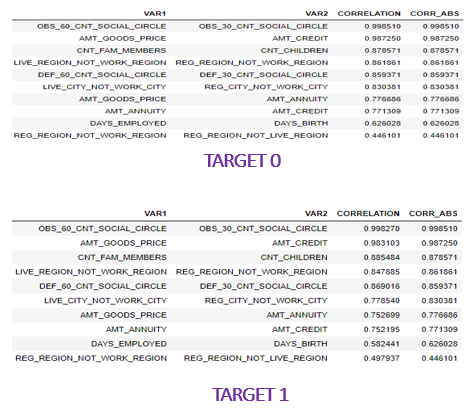

# 10. Loading  Data "previous_application.csv"

**10.0.1 Reading file**

In [ ]:
df2 = pd.read_csv("previous_application.csv")
df2.head()

**10.0.2 Shape of Dataframe**

In [ ]:
df2.shape

**10.0.3 Checking no. of columns with diffrent datatypes**

In [ ]:
df2.info()

**10.0.4 Checking the summary for the numeric columns**

In [ ]:
df2.describe()

**10.0.5 Sorting Percentage of null values in each column in desending  order**

In [ ]:
(df2.isnull().sum()/len(df2)*100).sort_values(ascending = False).head(30)

## 10.1 Data Cleaning

**10.1.1 List of Columns & null counts where null values are more than 35%**

In [ ]:
null_col = df2.isnull().sum().sort_values(ascending = False)
null_col = null_col[null_col.values >(0.35*len(df2))]

plt.figure(figsize=(20,4))
null_col.plot(kind='bar', color="#4CB391")
plt.title('List of Columns & null counts where null values are more than 35%')
plt.show()

**10.1.2 Total no.of columns having percentage of null values > 35%**

In [ ]:
len(null_col)

**10.1.3 Removing the columns having percentage of null values > 35%**

In [ ]:

label = list(null_col.index.values) #Making list of column names having null values greater than 35%
df2.drop(labels = label,axis=1,inplace = True) #Droping those columns


**10.1.4 Shape of new data frame after removing null values >35%**

In [ ]:
df2.shape

**10.1.5 Checking the % of null values for each column in new dataset again for confirmation**

In [ ]:
null = (df2.isnull().sum()/len(df2)*100).sort_values(ascending = False).head(50)
null.head(30)

## 10.3 Handling Missing Values       

### 10.3.1 Imputing Columns having null values ≤ 25% with Mode values for numeric columns except for continuous numeric columns we imputed with Median value

In [ ]:
df2.AMT_GOODS_PRICE.fillna(df2.AMT_GOODS_PRICE.median(),inplace = True)

df2.AMT_ANNUITY.fillna(df2.AMT_ANNUITY.mode()[0],inplace = True)

df2.CNT_PAYMENT.fillna(df2.CNT_PAYMENT.mode()[0],inplace = True)

**10.3.2 Checking  if there are still null values or not in the dataframe**

In [ ]:
(df2.isnull().sum()/len(df2)*100).sort_values(ascending=False)

## 10.4 Handling Errors

**10.4.1 Removing the column values of 'XNA' and 'XAP'**

In [ ]:
df2=df2.drop(df2[df2['NAME_CASH_LOAN_PURPOSE']=='XNA'].index)
df2=df2.drop(df2[df2['NAME_CASH_LOAN_PURPOSE']=='XNA'].index)
df2=df2.drop(df2[df2['NAME_CASH_LOAN_PURPOSE']=='XAP'].index)

df2.shape  #Cheking shape after removing 

**10.4.2 Merging the Application dataset with previous appliaction dataset by creating new variable** ***`"df3"`***

In [ ]:
df3 = pd.merge(left=df1, right=df2, how='inner', on='SK_ID_CURR', suffixes=('_x', '_y'))

**10.4.3 Renaming the column names after merging**


In [ ]:
df3 = df3.rename({'NAME_CONTRACT_TYPE_' : 'NAME_CONTRACT_TYPE','AMT_CREDIT_':'AMT_CREDIT','AMT_ANNUITY_':'AMT_ANNUITY',
                         'WEEKDAY_APPR_PROCESS_START_' : 'WEEKDAY_APPR_PROCESS_START',
                         'HOUR_APPR_PROCESS_START_':'HOUR_APPR_PROCESS_START','NAME_CONTRACT_TYPEx':'NAME_CONTRACT_TYPE_PREV',
                         'AMT_CREDITx':'AMT_CREDIT_PREV','AMT_ANNUITYx':'AMT_ANNUITY_PREV',
                         'WEEKDAY_APPR_PROCESS_STARTx':'WEEKDAY_APPR_PROCESS_START_PREV',
                         'HOUR_APPR_PROCESS_STARTx':'HOUR_APPR_PROCESS_START_PREV'}, axis=1)


## 10.5 Loan Distributions and Purposes

### 10.5.1  Percentage Count of  `NAME_CONTRACT_STATUS` and `NAME_CLIENT_TYPE`

In [ ]:
# Create subplots with adjusted figure size
fig = make_subplots(rows=1, cols=2, subplot_titles=("Percentage of NAME_CLIENT_TYPE", "Percentage of NAME_CONTRACT_STATUS"),
                    specs=[[{'type': 'domain'}, {'type': 'domain'}]])

# Add pie charts to the subplots
fig.add_trace(go.Pie(labels=df3['NAME_CLIENT_TYPE'].value_counts().index.to_list(),
                     values=df3['NAME_CLIENT_TYPE'].value_counts().to_list(), textinfo='label+percent'), 1, 1)

fig.add_trace(go.Pie(labels=df3['NAME_CONTRACT_STATUS'].value_counts().index.to_list(),
                     values=df3['NAME_CONTRACT_STATUS'].value_counts().to_list(), textinfo='label+percent'), 1, 2)

# Update traces to create donut-like pie charts
fig.update_traces(hole=.4, showlegend=False)

# Update layout to adjust figure size and margins
fig.update_layout(
    autosize=False,
    width=1000,  # Adjust width as needed
    height=500,  # Adjust height as needed
    margin=dict(l=50, r=50, b=50, t=50, pad=4)
)

# Show the plot
fig.show()

## Insights:
**`NAME_CLIENT_TYPE`**
- Around 80.7% clients were repeaters applying for loan.
- 14.5% clients are new applying for the loan.

**`NAME_CONTRACT_STATUS`**

Percentage of contracts approved or not in previous applications

- Approved     :- 38.8%
- Refused      :- 58.5%
- Canceled     :- 2.3%
- Unused offer :- 0.31%

In [ ]:
df3.CHANNEL_TYPE.value_counts()

### 10.5.2 **`NAME_CONTRACT_STATUS`** **with** **`NAME_CASH_LOAN_PURPOSE`** **based on  logarithmic scale**

In [ ]:
sns.set_style('darkgrid')
sns.set_context('poster')
plt.figure(figsize=(10,22))
plt.rcParams["axes.labelsize"] = 30
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.titlepad'] = 30
plt.xticks(rotation=45)
plt.yticks(fontsize=16)
plt.xscale('log')
plt.title('Distribution of contract status with loan purposes')



ax = sns.countplot(data = df3, y= 'NAME_CASH_LOAN_PURPOSE', 
                   order=df3['NAME_CASH_LOAN_PURPOSE'].value_counts().index,hue = 'NAME_CONTRACT_STATUS',palette='pastel')



## Insight:


- Most rejection of loans came from purpose **`"Repairs"`**.

- For **`"Education"`** & **`"Medicine"`** purposes we have equal number of approves and rejection

- **`"Payign other loans"`** and **`"Buying a new car'`** is having significant higher rejection than approves.



In [ ]:
# sns.set_style('darkgrid')
# sns.set_context('poster')
# plt.figure(figsize=(10,22))
# plt.rcParams["axes.labelsize"] = 30
# plt.rcParams['axes.titlesize'] = 30
# plt.rcParams['axes.titlepad'] = 30
# plt.xticks(rotation=45)
# plt.yticks(fontsize=16)
# plt.xscale('log')
# plt.title('Distribution of Target with Purposes of loan ')

# ax = sns.countplot(data = df3, y= 'NAME_CASH_LOAN_PURPOSE', 
#                    order=df3['NAME_CASH_LOAN_PURPOSE'].value_counts().index,hue = 'TARGET',palette='pastel')



## Insight:


- Here also there is a high variation for  **`"Repairs"`** for both the targets 

- Comparing **`"Education"`** & **`"Medicine"`** purposes ,  Medicine  there is high no. of cliets having difficulties for re payement the loan amount compare to **`"Education"`**

- **`Buying used Car`"** and **`Building purpose`** client having difficulties in payment have equal ratio

## 10.6 Distibution between **`AMT_CREDIT`** &  **`NAME_HOUSING_TYPE`** **based on  logarithmic scale**

**10.6.1 Checking the columns in the new dataframe**

In [ ]:
df3.columns

**10.6.2 Barplot Distibution** for columns **`AMT_CREDIT`** &  **`NAME_HOUSING_TYPE`**

In [ ]:
plt.figure(figsize=(11, 9))
plt.rcParams["axes.labelsize"] = 15
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.titlepad'] = 30
sns.barplot(data=df3, y='AMT_CREDIT_x', hue='TARGET', x='NAME_HOUSING_TYPE', palette='Dark2')
plt.title("Distribution for columns AMT_CREDIT & NAME_HOUSING_TYPE\n")
plt.xticks(fontsize=13, rotation=45)
plt.yticks(fontsize=13, rotation=360)
plt.show()

## Insight:
- Here for Housing type, office appartment is having higher credit of target 0 and co-op apartment is having higher credit of target 1. So, we can conclude that bank should avoid giving loans to the housing type of co-op apartment as they are having difficulties in payment. Bank can focus mostly on housing type with parents or House\appartment or miuncipal appartment for successful payments.





















# FINAL  CONCLUSION

**After all these analysis we conculded that** 

- We observe a decrease in the percentage of Payment Difficulties who are pentioners and an increase in the percentage of Payment Difficulties who are working when compared the percentages of both Payment Difficulties and non-Payment Difficulties.


- We observe a decrease in the percentage of married and widowed with Loan Payment Difficulties and an increase in the the percentage of single and civil married with Loan Payment Difficulties when comapred with the percentages of both Loan Payment Difficulties and Loan Non-Payment Difficulties


- We observe an increase in percentage of Loan Payment Difficulties whose educational qualifications are secondary/secondary special and a decrease in the percentage of Loan Payment Difficulties who have completed higher education when compared with the percentages of Loan Payment Difficulties and Loan Non-Payment Difficulties



- The count of ‘Low skilled Laborers’ in ‘OCCUPATION_TYPE’ is comparatively very less and it also has maximum % of payment difficulties- around 17%. Hence, client with occupation type as ‘Low skilled Laborers’ are the driving factors for Loan Defaulters.


- The count of ‘Lower Secondary’ in ‘NAME_EDUCATION_TYPE’ is comparatively very less and it also has maximum % of payment difficulties- around 11%. Hence, client with education type as ‘Lower Secondary’ are the driving factors for Loan Defaulters.


- Banks should focus more on contract type Student ,pensioner and Businessman with housing type other than Co-op apartment,Office apartment for successful payments.


- Banks should focus less on income type Working as they are having most number of unsuccessful payments.


- Also with loan purpose Repair is having higher number of unsuccessful payments on time.


- Get as much as clients from housing type With parents as they are having least number of unsuccessful payments.
